In [6]:
import kagglehub
import os

path = kagglehub.dataset_download("ayush1220/cifar10")

print("Dataset Path:", path)

dataset_root = os.path.join(path, "cifar10")

train_dir = os.path.join(dataset_root, "train")
test_dir = os.path.join(dataset_root, "test")

print("Train Directory:", train_dir)
print("Test Directory:", test_dir)

for root, dirs, files in os.walk(path):
    print(root)
    print(files[:5])
    print("-"*50)

100%|██████████| 139M/139M [00:00<00:00, 166MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/ayush1220/cifar10/versions/2
Train Directory: /root/.cache/kagglehub/datasets/ayush1220/cifar10/versions/2/cifar10/train
Test Directory: /root/.cache/kagglehub/datasets/ayush1220/cifar10/versions/2/cifar10/test
/root/.cache/kagglehub/datasets/ayush1220/cifar10/versions/2
[]
--------------------------------------------------
/root/.cache/kagglehub/datasets/ayush1220/cifar10/versions/2/cifar10
[]
--------------------------------------------------
/root/.cache/kagglehub/datasets/ayush1220/cifar10/versions/2/cifar10/train
[]
--------------------------------------------------
/root/.cache/kagglehub/datasets/ayush1220/cifar10/versions/2/cifar10/train/automobile
['4820.png', '1832.png', '3707.png', '4877.png', '0931.png']
--------------------------------------------------
/root/.cache/kagglehub/datasets/ayush1220/cifar10/versions/2/cifar10/train/cat
['4820.png', '1832.png', '3707.png', '4877.png', '0931.png']
--------------------------------------

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Reshape,
    Multiply, Flatten, Dropout
)
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report

In [8]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(32,32),
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(32,32),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(32,32),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_data.class_indices)

print("Classes:", train_data.class_indices)

Found 40000 images belonging to 10 classes.
Found 10000 images belonging to 10 classes.
Found 10000 images belonging to 10 classes.
Classes: {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


In [9]:
def build_baseline_cnn():

    inputs = Input(shape=(32,32,3))

    x = Conv2D(32,(3,3),activation='relu',padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)

    x = Conv2D(64,(3,3),activation='relu',padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)

    x = Conv2D(128,(3,3),activation='relu',padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)

    x = Flatten()(x)

    x = Dense(256,activation='relu')(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes,activation='softmax')(x)

    return Model(inputs,outputs)

In [10]:
baseline_model = build_baseline_cnn()

baseline_model.compile(
    optimizer=Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 73ms/step - accuracy: 0.4405 - loss: 1.5716 - val_accuracy: 0.4656 - val_loss: 1.5364
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.5696 - loss: 1.2061 - val_accuracy: 0.5365 - val_loss: 1.3077
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.6249 - loss: 1.0642 - val_accuracy: 0.6135 - val_loss: 1.1373
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.6622 - loss: 0.9641 - val_accuracy: 0.5217 - val_loss: 1.4273
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.6847 - loss: 0.8979 - val_accuracy: 0.6826 - val_loss: 0.8996


In [11]:
def se_block(feature_map, reduction=8):

    channels = feature_map.shape[-1]

    se = GlobalAveragePooling2D()(feature_map)

    se = Dense(
        channels // reduction,
        activation='relu'
    )(se)

    se = Dense(
        channels,
        activation='sigmoid'
    )(se)

    se = Reshape((1,1,channels))(se)

    return Multiply()([feature_map,se])

In [12]:
def build_se_cnn():

    inputs = Input(shape=(32,32,3))

    x = Conv2D(32,(3,3),activation='relu',padding='same')(inputs)
    x = BatchNormalization()(x)

    x = se_block(x)

    x = MaxPooling2D()(x)

    x = Conv2D(64,(3,3),activation='relu',padding='same')(x)
    x = BatchNormalization()(x)

    x = se_block(x)

    x = MaxPooling2D()(x)

    x = Conv2D(128,(3,3),activation='relu',padding='same')(x)
    x = BatchNormalization()(x)

    x = se_block(x)

    x = MaxPooling2D()(x)

    x = Flatten()(x)

    x = Dense(256,activation='relu')(x)

    x = Dropout(0.3)(x)

    outputs = Dense(num_classes,activation='softmax')(x)

    return Model(inputs,outputs)

In [13]:
se_model = build_se_cnn()

se_model.compile(
    optimizer=Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_se = se_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 74ms/step - accuracy: 0.4893 - loss: 1.4235 - val_accuracy: 0.3997 - val_loss: 1.8935
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.6179 - loss: 1.0750 - val_accuracy: 0.5988 - val_loss: 1.1393
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.6694 - loss: 0.9360 - val_accuracy: 0.6134 - val_loss: 1.1029
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.6981 - loss: 0.8511 - val_accuracy: 0.5913 - val_loss: 1.1320
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.7184 - loss: 0.8015 - val_accuracy: 0.5608 - val_loss: 1.3616


In [14]:
base_loss, base_acc = baseline_model.evaluate(test_data)

se_loss, se_acc = se_model.evaluate(test_data)

print("\nRESULT COMPARISON")
print("-"*40)

print(f"Baseline CNN Accuracy : {base_acc:.4f}")

print(f"SE-CNN Accuracy       : {se_acc:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7004 - loss: 0.8948
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5986 - loss: 1.2531

RESULT COMPARISON
----------------------------------------
Baseline CNN Accuracy : 0.7004
SE-CNN Accuracy       : 0.5986


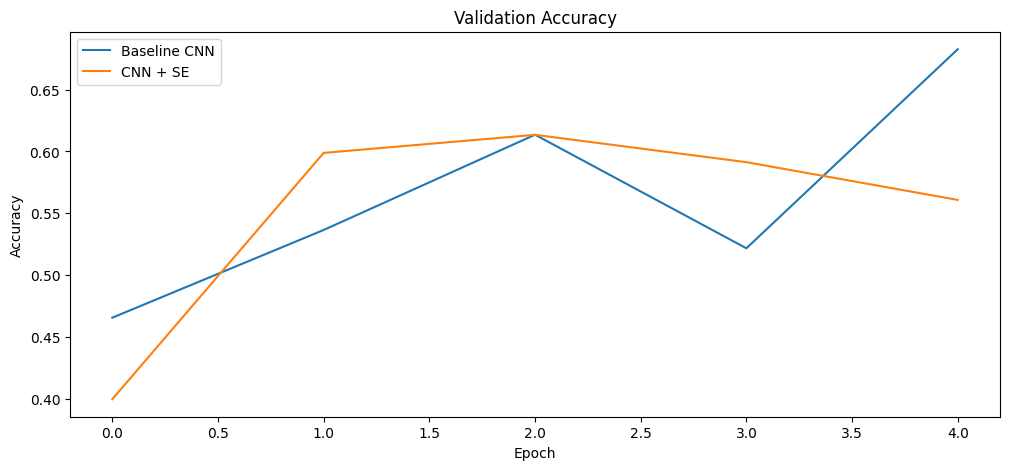

In [15]:
plt.figure(figsize=(12,5))

plt.plot(
    history_baseline.history['val_accuracy'],
    label='Baseline CNN'
)

plt.plot(
    history_se.history['val_accuracy'],
    label='CNN + SE'
)

plt.title("Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [16]:
predictions = se_model.predict(test_data)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes

class_names = list(test_data.class_indices.keys())

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step
              precision    recall  f1-score   support

    airplane       0.51      0.84      0.63      1000
  automobile       0.70      0.92      0.80      1000
        bird       0.35      0.74      0.47      1000
         cat       0.57      0.30      0.39      1000
        deer       0.79      0.16      0.26      1000
         dog       0.86      0.22      0.35      1000
        frog       0.60      0.83      0.69      1000
       horse       0.87      0.54      0.67      1000
        ship       0.73      0.69      0.71      1000
       truck       0.77      0.76      0.76      1000

    accuracy                           0.60     10000
   macro avg       0.68      0.60      0.57     10000
weighted avg       0.68      0.60      0.57     10000



2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


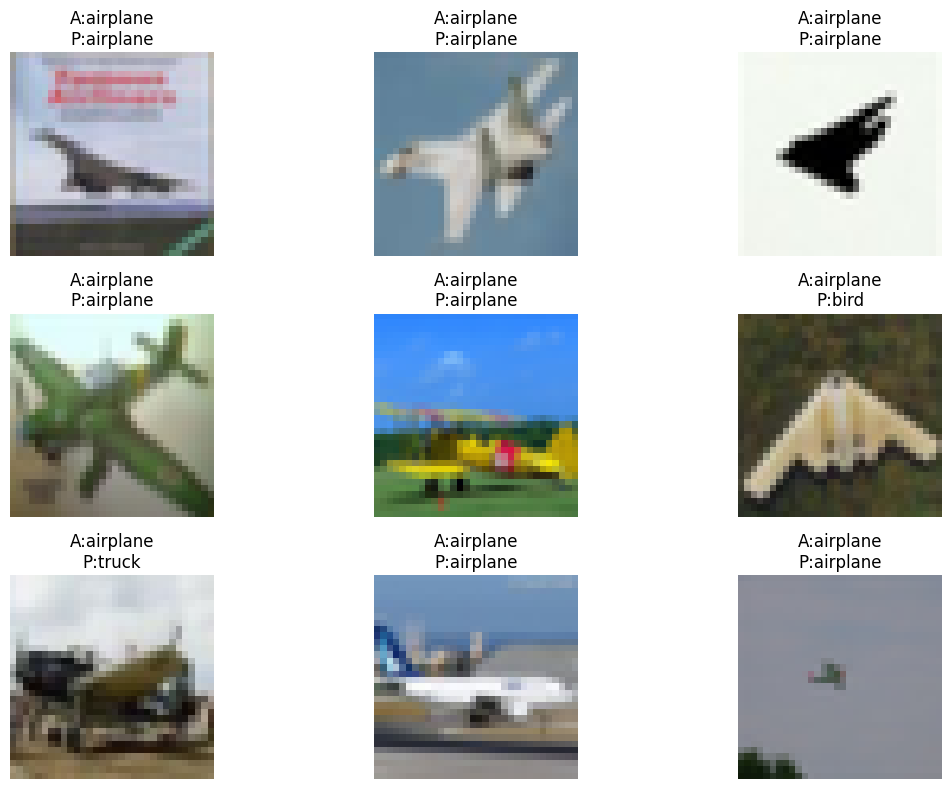

In [17]:
images, labels = next(test_data)

preds = se_model.predict(images)

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    actual = class_names[np.argmax(labels[i])]

    predicted = class_names[np.argmax(preds[i])]

    plt.title(f"A:{actual}\nP:{predicted}")

    plt.axis("off")

plt.tight_layout()

plt.show()